In [1]:
!pip install ucimlrepo

In [18]:
!pip install pygame

   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------- ----------- 7.6/10.6 MB 57.9 MB/s eta 0:00:01
   ---------------------------------------- 10.6/10.6 MB 53.3 MB/s  0:00:00


Import necesarios

In [19]:
import pandas as pd
import numpy as np
from scipy.signal import butter, lfilter
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import pygame

pygame 2.6.1 (SDL 2.28.4, Python 3.13.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


c:\Users\User\anaconda3\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Traer los datos de EEG Eye State

In [3]:

# fetch dataset 
eeg_eye_state = fetch_ucirepo(id=264) 

# data (as pandas dataframes) 
X = eeg_eye_state.data.features 
y = eeg_eye_state.data.targets 

# metadata 
print(eeg_eye_state.metadata) 

# variable information 
print(eeg_eye_state.variables) 


{'uci_id': 264, 'name': 'EEG Eye State', 'repository_url': 'https://archive.ics.uci.edu/dataset/264/eeg+eye+state', 'data_url': 'https://archive.ics.uci.edu/static/public/264/data.csv', 'abstract': 'The data set consists of 14 EEG values and a value indicating the eye state.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 14980, 'num_features': 14, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['eyeDetection'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Thu Mar 21 2024', 'dataset_doi': '10.24432/C57G7J', 'creators': ['Oliver Roesler'], 'intro_paper': None, 'additional_info': {'summary': "All data is from one continuous EEG measurement with the Emotiv EEG Neuroheadset. The duration of the measurement was 117 seconds. The eye state was detected via a camera during the EEG measuremen

Visualizar la forma de los primeros 25 datos

In [4]:
X.head(25)

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46
5,4321.03,4004.62,4284.10,4153.33,4345.64,4587.18,4093.33,4616.92,4202.56,4232.82,4209.74,4281.03,4628.21,4389.74
6,4319.49,4001.03,4280.51,4151.79,4343.59,4584.62,4089.74,4615.90,4212.31,4226.67,4201.03,4269.74,4625.13,4378.46
7,4325.64,4006.67,4278.46,4143.08,4344.10,4583.08,4087.18,4614.87,4205.64,4230.26,4195.90,4266.67,4622.05,4380.51
8,4326.15,4010.77,4276.41,4139.49,4345.13,4584.10,4091.28,4608.21,4187.69,4229.74,4202.05,4273.85,4627.18,4389.74
9,4326.15,4011.28,4276.92,4142.05,4344.10,4582.56,4092.82,4608.72,4194.36,4228.72,4212.82,4277.95,4637.44,4393.33


Imprimir amplitud vs tiempo originales

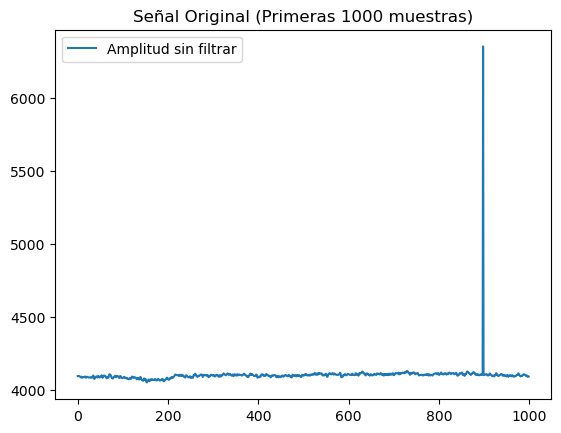

In [16]:
plt.plot(X['O1'][:1000], label='Amplitud sin filtrar')
plt.title('Señal Original (Primeras 1000 muestras)')
plt.legend()
plt.show()

Imprimir amplitud vs tiempo filtradas (se limpian los datos para dejarlos "centrados" en 0, además se aplican filtros pasa banda para aislar frecuencias alpha y beta)

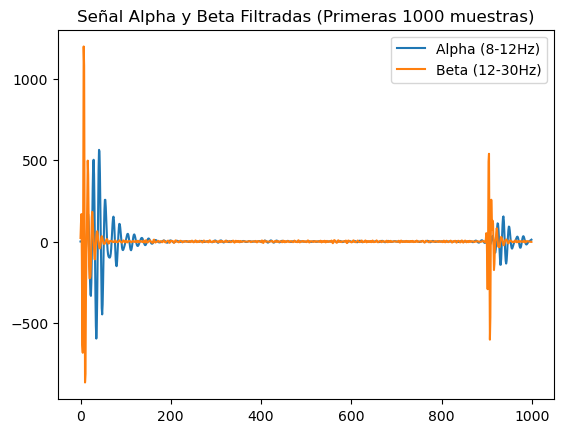

In [ ]:
fs = 128.0  # Frecuencia de muestreo comun del Emotiv (sensor de EEG)

# Función que hace el filtro Butterworth/Pasa banda (scipy.signal.butter) y luego aplica el filtro a la señal (scipy.signal.lfilter)
def filtro_butter(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def aplicar_filtro(data, lowcut, highcut, fs, order=5):
    b, a = filtro_butter(lowcut, highcut, fs, order=order)
    return lfilter(b, a, data)

# Se selecciona un canal (O1 es el mas usado para la señal Alpha)
raw_signal = X['O1'].values 

# Aplicamos filtros anteriormente definidos para obtener las señales Alpha y Beta
alpha_signal = aplicar_filtro(raw_signal, 8, 12, fs)
beta_signal = aplicar_filtro(raw_signal, 12, 30, fs)

# Visualización
plt.plot(alpha_signal[:1000], label='Alpha (8-12Hz)')
plt.plot(beta_signal[:1000], label='Beta (12-30Hz)')
plt.title('Señal Alpha y Beta Filtradas (Primeras 1000 muestras)')
plt.legend()
plt.show()


Definición de la condición de control, se calcula la Potencia cuadrática Media de ventanas de tiempo (forma de describir como cambia la "intensidad" de la señal a lo largo del tiempo); además se define un umbral para hacer ejecutar una acción visual

In [20]:
# Función que calcula la potencia de una señal usando una ventana móvil
def potencia(signal, window_size=64):
    return np.sqrt(np.convolve(signal**2, np.ones(window_size)/window_size, mode='same'))

alpha_power = potencia(alpha_signal)

# Definimos un umbral 
# Usualmente el umbral se toma como el promedio de la señal + 1 desviación estándar
umbral = np.mean(alpha_power) + np.std(alpha_power)

In [22]:
print(len(alpha_power))

14980


Ejecución de la simulación, se va a recorrer la señal alpha calculando la potencia de la ventana, si la potencia supera el umbral se tomará como una activación cerebral que cambiará de color una ventana de pygame

In [ ]:
# Configauración e iniciación de Pygame 
pygame.init()
screen = pygame.display.set_mode((800, 800))
pygame.display.set_caption('Simulación BCI: Detección de Actividad Cerebral')
fuente = pygame.font.SysFont("Arial", 40)
reloj = pygame.time.Clock()
fps = 30

ejecutando = True
estado_cerebro = False # False: No se detecta actividad, True: Se detecta actividad
i = 0

while ejecutando:
    # Evento para finalizar la simulación
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            ejecutando = False
    
    # Simulamos la detección de actividad cerebral comparando la potencia Alpha con el umbral
    if alpha_power[i] > umbral:  # Recorremos el arreglo de potencia Alpha 
        estado_cerebro = True
    else:
        estado_cerebro = False
    
    # Cambiamos el color de fondo según el estado del cerebro
    if estado_cerebro:
        screen.fill((0, 255, 0))  # Verde si se detecta actividad
        estado = "Actividad Detectada"
    else:
        screen.fill((255, 0, 0))  # Rojo si no se detecta actividad
        estado = "No se Detecta Actividad"

    # Mostramos el estado y la potencia Alpha en la pantalla
    estado_texto = fuente.render(f"{estado}", True, (255, 255, 255))
    screen.blit(estado_texto, (10, 10))
    potencia_texto = fuente.render(f"Potencia Alpha: {alpha_power[i]:.2f}", True, (255, 255, 255))
    screen.blit(potencia_texto, (10, 70))
    umbral_texto = fuente.render(f"Umbral: {umbral:.2f}", True, (255, 255, 255))
    screen.blit(umbral_texto, (10, 130))

    # Actualizar la pantalla
    pygame.display.flip()

    i += 50 # se incrementa el indice de 50 en 50 para que no se demore tanto en recorrer el arreglo de potencia Alpha (14000 muestras)
    if i >= len(alpha_power):
        i = 0  # Reiniciamos el índice para simular continuamente
    
    # Sincronizar el reloj para poder ver la simulación a una velocidad adecuada
    reloj.tick(fps)
    
pygame.quit()

